Hello World Graph!

In [1]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
  message: str

def greeting_node(state: AgentState) -> AgentState:

  '''Simple node that adds greeting to the state'''

  state['message'] = "Hey " + state['message'] + "! How are you doing?"

  return state

In [4]:
graph1 = StateGraph(AgentState)
graph1.add_node("greeter",greeting_node)

graph1.set_entry_point("greeter")

graph1.set_finish_point("greeter")

app1 = graph1.compile()

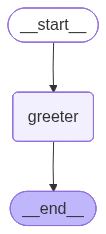

In [5]:
from IPython.display import Image, display
display(Image(app1.get_graph().draw_mermaid_png()))

In [6]:
result = app1.invoke({"message": "Suraj"})

In [8]:
result["message"]

'Hey Suraj! How are you doing?'

***Multi input Graph***

In [9]:
from typing import Dict,TypedDict, List
from langgraph.graph import StateGraph

In [10]:
class AgentState(TypedDict):
  values: List[int]
  name: str
  result: str



In [19]:
def process_values(state: AgentState) -> AgentState:
  '''This function processes multiple different values input'''
  print(state)

  state['result'] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"

  print(state)

  return state


In [20]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()


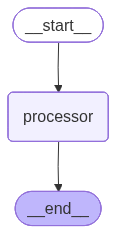

In [21]:
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
res = app.invoke({'values':[4,2,6,7,82,5], 'name':'Suraj'})

{'values': [4, 2, 6, 7, 82, 5], 'name': 'Suraj'}
{'values': [4, 2, 6, 7, 82, 5], 'name': 'Suraj', 'result': 'Hi there Suraj! Your sum = 106'}


In [18]:
res['result']

'Hi there Suraj! Your sum = 106'

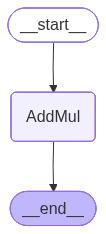

'Hi Suraj! Your result is 30720'

In [25]:
import math

class AgentState2(TypedDict):
  name: str
  values: List[int]
  operator: chr
  result: str

def operation(state: AgentState2) -> AgentState2:
  '''Apply the operation that user wants on the list input by the user himself'''

  if(state['operator'] == '+'):
    state['result'] = f"Hi {state["name"]}! Your result is {sum(state['values'])}"
  elif(state['operator'] == '*'):
    state['result'] = f"Hi {state["name"]}! Your result is {math.prod(state['values'])}"

  return state

graph = StateGraph(AgentState2)
graph.add_node("AddMul",operation)
graph.set_entry_point("AddMul")
graph.set_finish_point("AddMul")

app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

res = app.invoke({"name": "Suraj","values": [5,8,32,3,8], "operator": '*'})
res["result"]

***Multiple Nodes***

In [27]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [28]:
class AgentState(TypedDict):
  name: str
  age: str
  final: str

def first_node(state: AgentState) -> AgentState:
  '''This is the first node in the sequential graph'''

  state['final'] = f"Hi {state["name"]}!"

  return state

def second_node(state: AgentState) -> AgentState:
  '''This is the second node in the sequential graph'''

  state['final'] = state['final'] + f" I really couldn't believe you are {state['age']} years old now!"

  return state



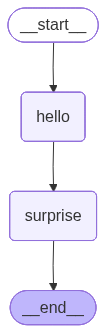

In [33]:
graph = StateGraph(AgentState)
graph.add_node("hello", first_node)
graph.add_node("surprise", second_node)
graph.set_entry_point("hello")
graph.add_edge("hello", "surprise")
graph.set_finish_point("surprise")


app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [34]:
app.invoke({"name": "Suraj", "age": "21"})

{'name': 'Suraj',
 'age': '21',
 'final': "Hi Suraj! I really couldn't believe you are 21 years old now!"}

***Conditional Edges***

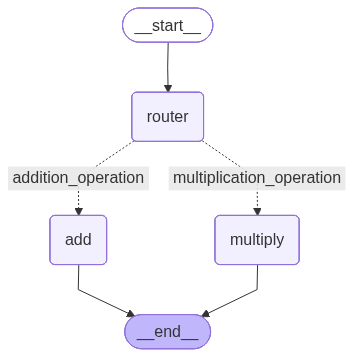

In [43]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from typing import List, TypedDict

class AgentState(TypedDict):
  num1: int
  operator: chr
  num2: int
  res: int

def adder(state: AgentState) -> AgentState:
  '''This function adds the numbers in the state'''

  state['res'] = state['num1'] + state['num2']

  return state

def multiplier(state: AgentState) -> AgentState:
  '''This function mulitplies the two numbers in the state'''

  state['res'] = state['num1'] * state['num2']

  return state

def decider(state: AgentState) -> AgentState:
  '''This node chooses which node to invoke further'''

  if(state['operator'] == '+'):
    return "addition_operation"
  elif(state['operator'] == '*'):
    return "multiplication_operation"


graph = StateGraph(AgentState)
graph.add_node('add', adder)
graph.add_node('multiply', multiplier)
graph.add_node('router', lambda state: state)

graph.add_edge(START, 'router')

graph.add_conditional_edges(
    "router",
    decider,
    {
        "addition_operation": "add",
        "multiplication_operation": "multiply"
    }
)

graph.add_edge('add', END)
graph.add_edge('multiply', END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [44]:
app.invoke({"num1": 5, "operator": "+", "num2": 33})

{'num1': 5, 'operator': '+', 'num2': 33, 'res': 38}

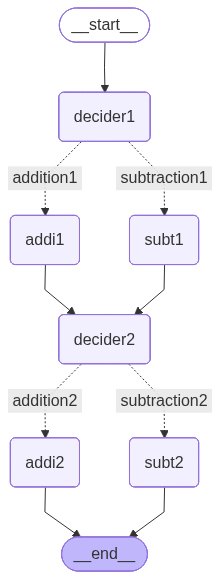

{'num1': 56,
 'num2': 50,
 'num3': 9,
 'num4': 10,
 'operator1': '-',
 'operator2': '+',
 'res1': 6,
 'res2': 19}

In [51]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List

class AgentState(TypedDict):
  num1: int
  num2: int
  num3: int
  num4: int
  operator1: chr
  operator2: chr
  res1: int
  res2: int

def add1(state: AgentState)->AgentState:
  '''This function is first addition point'''
  state['res1'] = state['num1'] + state['num2']
  return state

def add2(state: AgentState)->AgentState:
  '''This function is first addition point'''
  state['res2'] = state['num3'] + state['num4']
  return state

def sub1(state: AgentState)->AgentState:
  '''This function is first subtraction point'''
  state['res1'] = state['num1'] - state['num2']
  return state

def sub2(state: AgentState)->AgentState:
  '''This function is second subtraction point'''
  state['res2'] = state['num3'] - state['num4']
  return state

def router1(state: AgentState)->AgentState:
  ''' This function is the first router function'''
  if(state['operator1'] == '+'):
    return "addition1"
  elif(state['operator1'] == '-'):
    return "subtraction1"

def router2(state: AgentState)->AgentState:
  '''This is the second router function'''

  if(state["operator2"] == '+'):
    return "addition2"
  elif(state["operator2"] == '-'):
    return "subtraction2"

graph = StateGraph(AgentState)

graph.add_node("addi1", add1)
graph.add_node("addi2", add2)
graph.add_node("subt1", sub1)
graph.add_node("subt2", sub2)

graph.add_node("decider1", lambda state:state)
graph.add_node("decider2", lambda state:state)

graph.add_edge(START, "decider1")

graph.add_conditional_edges(
    "decider1",
    router1,
    {
        "addition1": "addi1",
        "subtraction1": "subt1"
    }
)

graph.add_edge("addi1","decider2")
graph.add_edge("subt1","decider2")

graph.add_conditional_edges(
    "decider2",
    router2,
    {
        "addition2": "addi2",
        "subtraction2": "subt2"
    }
)

graph.add_edge("addi2",END)
graph.add_edge("subt2",END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

app.invoke({"num1": 56, "num2": 50, "operator1": '-', "num3": 9, "num4": 10, "operator2": '+'})

***Looping***

In [72]:
import random

class AgentState(TypedDict):
  name: str
  numbers: List[int]
  counter: int
  greeting: str

def greeting_node(state: AgentState)->AgentState:
  '''This is the greeting node'''

  state['greeting'] = f"Hi there {state['name']}! Hope you are doing well."
  state['counter'] = 0

  return state

def random_node(state: AgentState)->AgentState:
  '''this is a random node which will be looped, generates random integer between 0 and 10'''

  state['numbers'].append(random.randint(0,10))
  state['counter'] += 1

  return state

def router(state: AgentState)->AgentState:
  '''This is the router node which will ask at every iteration whether to loop back or end'''

  if(state['counter'] <= 20):
    print("Entering loop ", state['counter'])
    return "looping_edge"
  else:
    return "ending_edge"

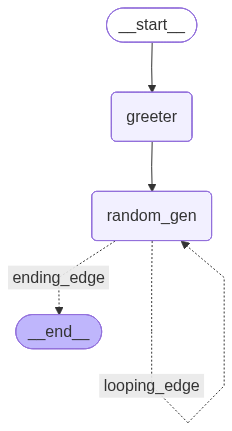

Entering loop  1
Entering loop  2
Entering loop  3
Entering loop  4
Entering loop  5
Entering loop  6
Entering loop  7
Entering loop  8
Entering loop  9
Entering loop  10
Entering loop  11
Entering loop  12
Entering loop  13
Entering loop  14
Entering loop  15
Entering loop  16
Entering loop  17
Entering loop  18
Entering loop  19
Entering loop  20


{'name': 'Suraj',
 'numbers': [7,
  3,
  10,
  8,
  10,
  8,
  1,
  7,
  3,
  0,
  4,
  8,
  7,
  4,
  8,
  5,
  10,
  7,
  3,
  4,
  10],
 'counter': 21,
 'greeting': 'Hi there Suraj! Hope you are doing well.'}

In [73]:
graph = StateGraph(AgentState)
graph.add_node("greeter",greeting_node)
graph.add_node("random_gen",random_node)

graph.add_edge(START, "greeter")
graph.add_edge("greeter", "random_gen")

graph.add_edge("random_gen", END)
graph.add_conditional_edges(
    "random_gen",
    router,
    {
        "ending_edge": END,
        "looping_edge": "random_gen"
    }
)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

app.invoke({"name": "Suraj", "numbers": [], "counter":-1})

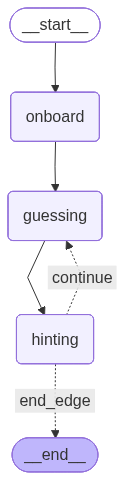

In [114]:
import random
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

class AgentState(TypedDict):
  player_name: str
  guesses: List[int]
  max_guesses: int
  attempts: int
  lower_bound: int
  upper_bound: int
  answer: int
  found: bool

def setup_node(state: AgentState)->AgentState:
  '''This is the onboarding node for the game'''

  print(f"Welcome to the game {state['player_name']}!")
  state['max_guesses'] = 7
  state['attempts'] = 0
  state['answer'] = random.randint(state['lower_bound'],state['upper_bound'])
  state['found'] = False
  return state

def guess_node(state: AgentState)->AgentState:
  '''This is the thinker node'''
  state['attempts'] += 1
  state['guesses'].append(random.randint(state['lower_bound'],state['upper_bound']))
  print(f"Guess number {state['attempts']} : {state['guesses'][-1]}")

  return state

def hinter(state: AgentState)->AgentState:
  '''This function provides the hint for the guesses'''
  if(state['guesses'][-1] == state['answer']):
    print('Hurray! You found the correct answer.')
    state['found'] = True
  else:
    if(state['guesses'][-1] < state['answer']):
      print('======> Guess higher <======')
      state['lower_bound'] = state['guesses'][-1] + 1
    else:
      print('======> Guess lower <======')
      state['upper_bound'] = state['guesses'][-1] - 1

  return state


def should_continue(state: AgentState)->AgentState:
  '''This function implements the logic for checking the condition for continuing loop or not'''

  if(state['attempts'] < 7 and not state['found']):
    return 'continue'
  else:
    return 'end_edge'

graph = StateGraph(AgentState)
graph.add_node("onboard", setup_node)
graph.add_node("guessing", guess_node)
graph.add_node("hinting", hinter)

graph.add_edge(START, "onboard")
graph.add_edge("onboard", "guessing")
graph.add_edge("guessing", "hinting")

graph.add_edge("hinting", END)

graph.add_conditional_edges(
    "hinting",
    should_continue,
    {
        "continue": "guessing",
        "end_edge": END
    }
)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [115]:
app.invoke({"player_name": "Suraj", "lower_bound": 1, "upper_bound": 20, "guesses": [], "attempts":660})

Welcome to the game Suraj!
Guess number 1 : 8
======> Guess lower <======
Guess number 2 : 3
======> Guess lower <======
Guess number 3 : 2
======> Guess lower <======
Guess number 4 : 1
Hurray! You found the correct answer.


{'player_name': 'Suraj',
 'guesses': [8, 3, 2, 1],
 'max_guesses': 7,
 'attempts': 4,
 'lower_bound': 1,
 'upper_bound': 1,
 'answer': 1,
 'found': True}